# Day 08. Exercise 05
# Clustering

## 0. Imports

In [99]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np


## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [100]:
df = pd.read_csv('../data/regression.csv')

df = df.drop(columns=['pageviews'])

print(df.head())

       uid  num_commits   AVG(diff)
0   user_1           62  -64.400000
1  user_10           20  -74.800000
2  user_14           61 -159.000000
3  user_17           51  -61.600000
4  user_18            5   -5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [101]:

X = df[['num_commits', 'AVG(diff)']].copy()
kmeans = KMeans(n_clusters=3, random_state=21)
labels = kmeans.fit_predict(X)


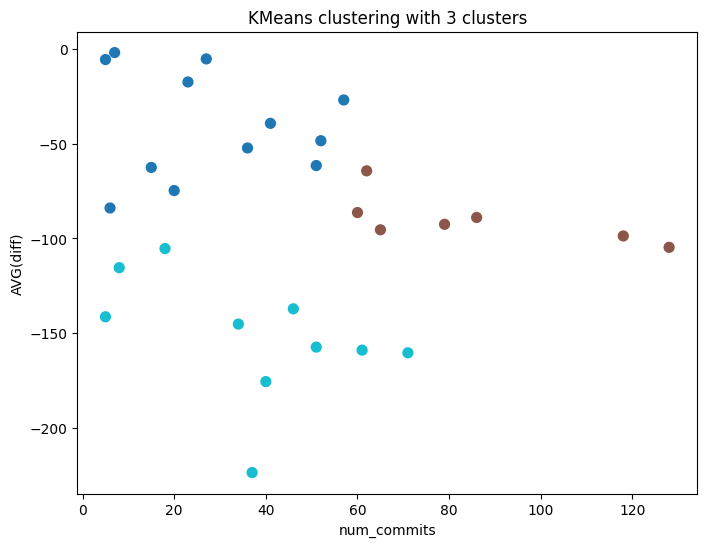

In [102]:
plt.figure(figsize=(8, 6))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='tab10', s=50)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title('KMeans clustering with 3 clusters')
plt.show()


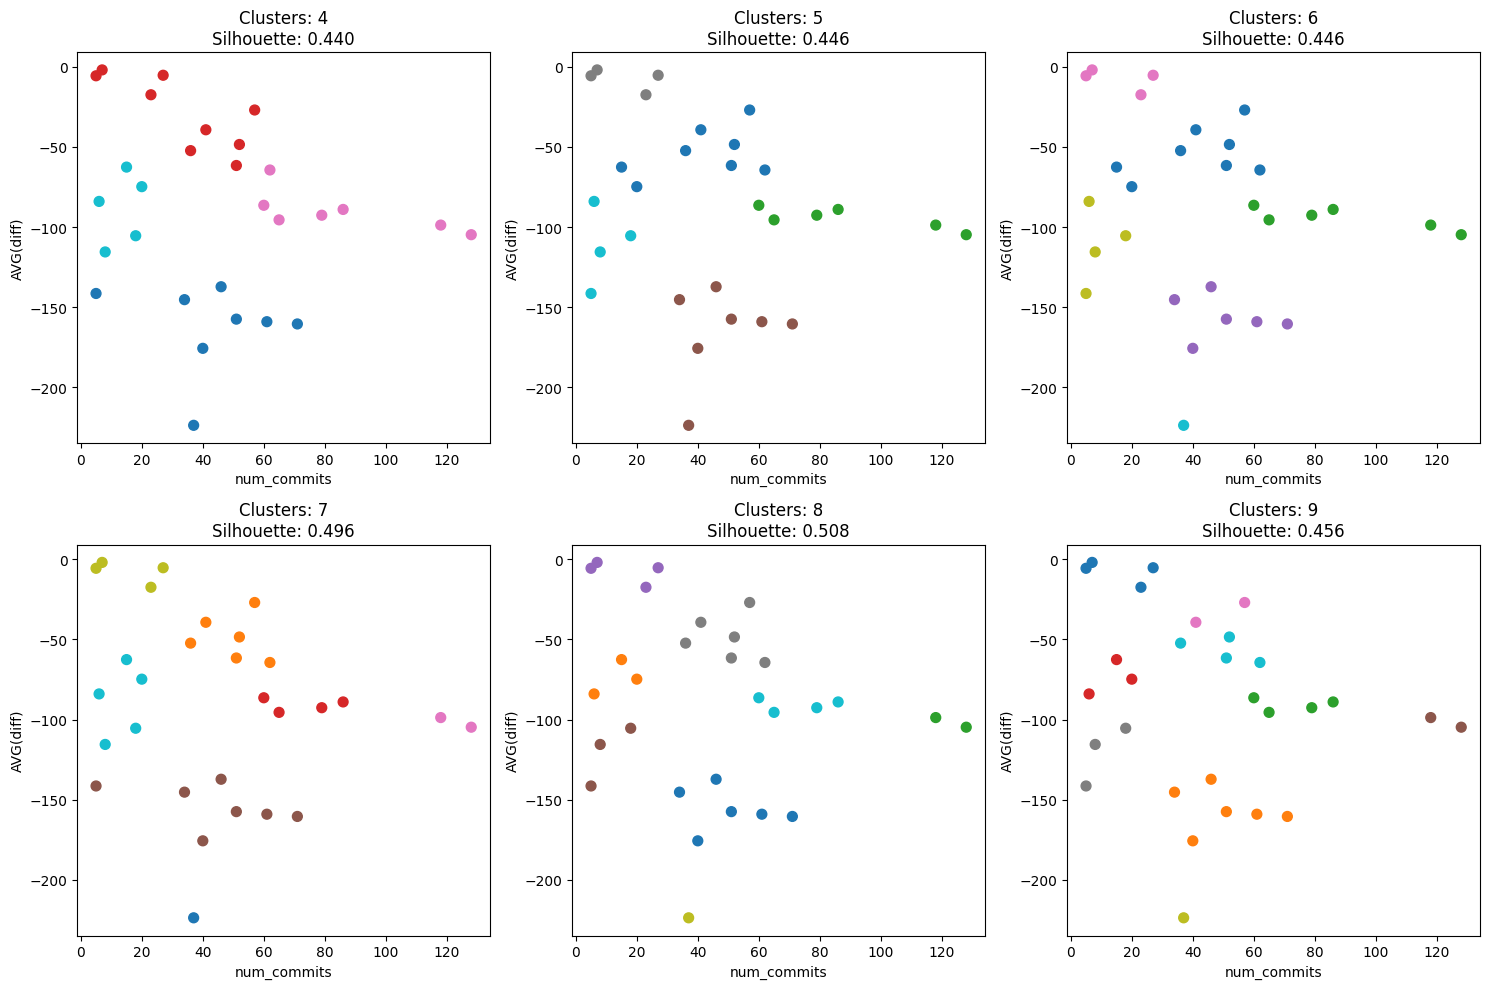

In [103]:
plt.figure(figsize=(15, 10))
n_clusters_list = [4, 5, 6, 7, 8, 9]
for idx, n_clusters in enumerate(n_clusters_list, start=1):
    kmeans = KMeans(n_clusters=n_clusters, random_state=21)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    plt.subplot(2, 3, idx)
    plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='tab10', s=50)
    plt.title(f'Clusters: {n_clusters}\nSilhouette: {score:.3f}')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')

plt.tight_layout()
plt.show()

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

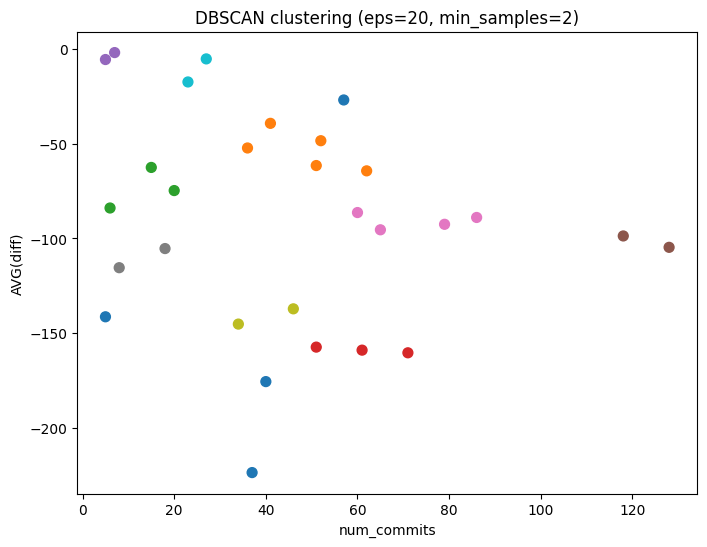

Silhouette score: 0.383


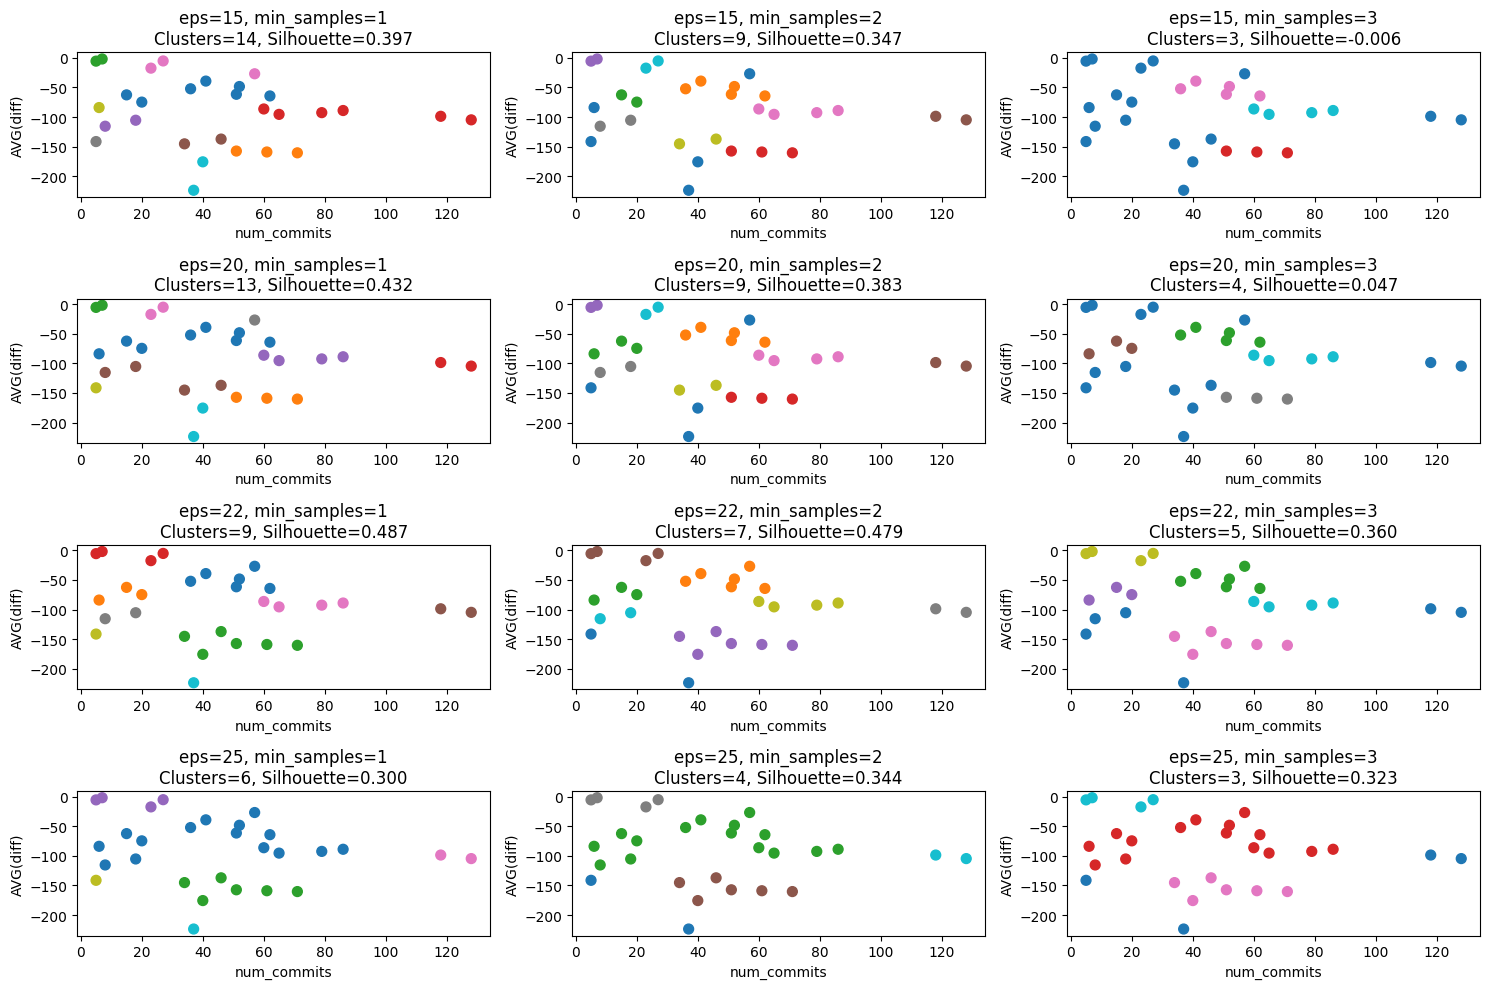

In [104]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='tab10', s=50)
plt.title('DBSCAN clustering (eps=20, min_samples=2)')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
if n_clusters > 1:
    try:
        score = silhouette_score(X, labels)
        if np.isnan(score):
            print('Silhouette score: nan (возможно, кластеры слишком малы или есть только выбросы)')
        else:
            print(f'Silhouette score: {score:.3f}')
    except Exception as e:
        print(f'Silhouette score невозможно посчитать: {e}')
else:
    print('Silhouette score невозможно посчитать: слишком мало кластеров (нашлось только', n_clusters, ')')

eps_values = [15, 20, 22, 25]
min_samples_values = [1, 2, 3]

plt.figure(figsize=(15, 10))
plot_num = 1
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            try:
                score = silhouette_score(X, labels)
                if np.isnan(score):
                    
                    score_str = 'nan'
                else:
                    score_str = f'{score:.3f}'
            except Exception as e:
                score_str = 'err'
        else:
            score_str = f'мало кластеров ({n_clusters})'

        plt.subplot(len(eps_values), len(min_samples_values), plot_num)
        plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='tab10', s=50)
        plt.title(f'eps={eps}, min_samples={min_samples}\nClusters={n_clusters}, Silhouette={score_str}')
        plt.xlabel('num_commits')
        plt.ylabel('AVG(diff)')
        plot_num += 1

plt.tight_layout()
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

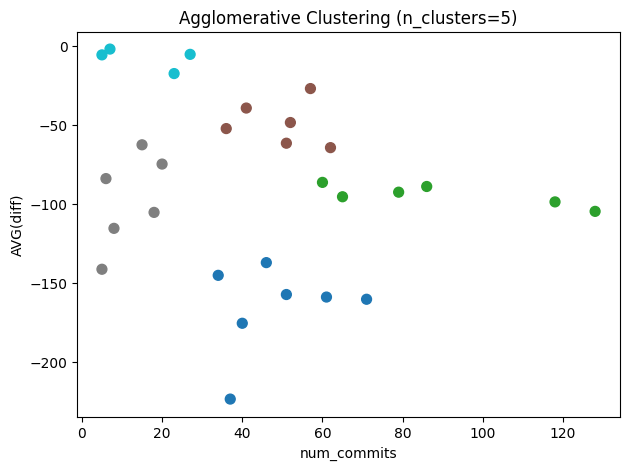

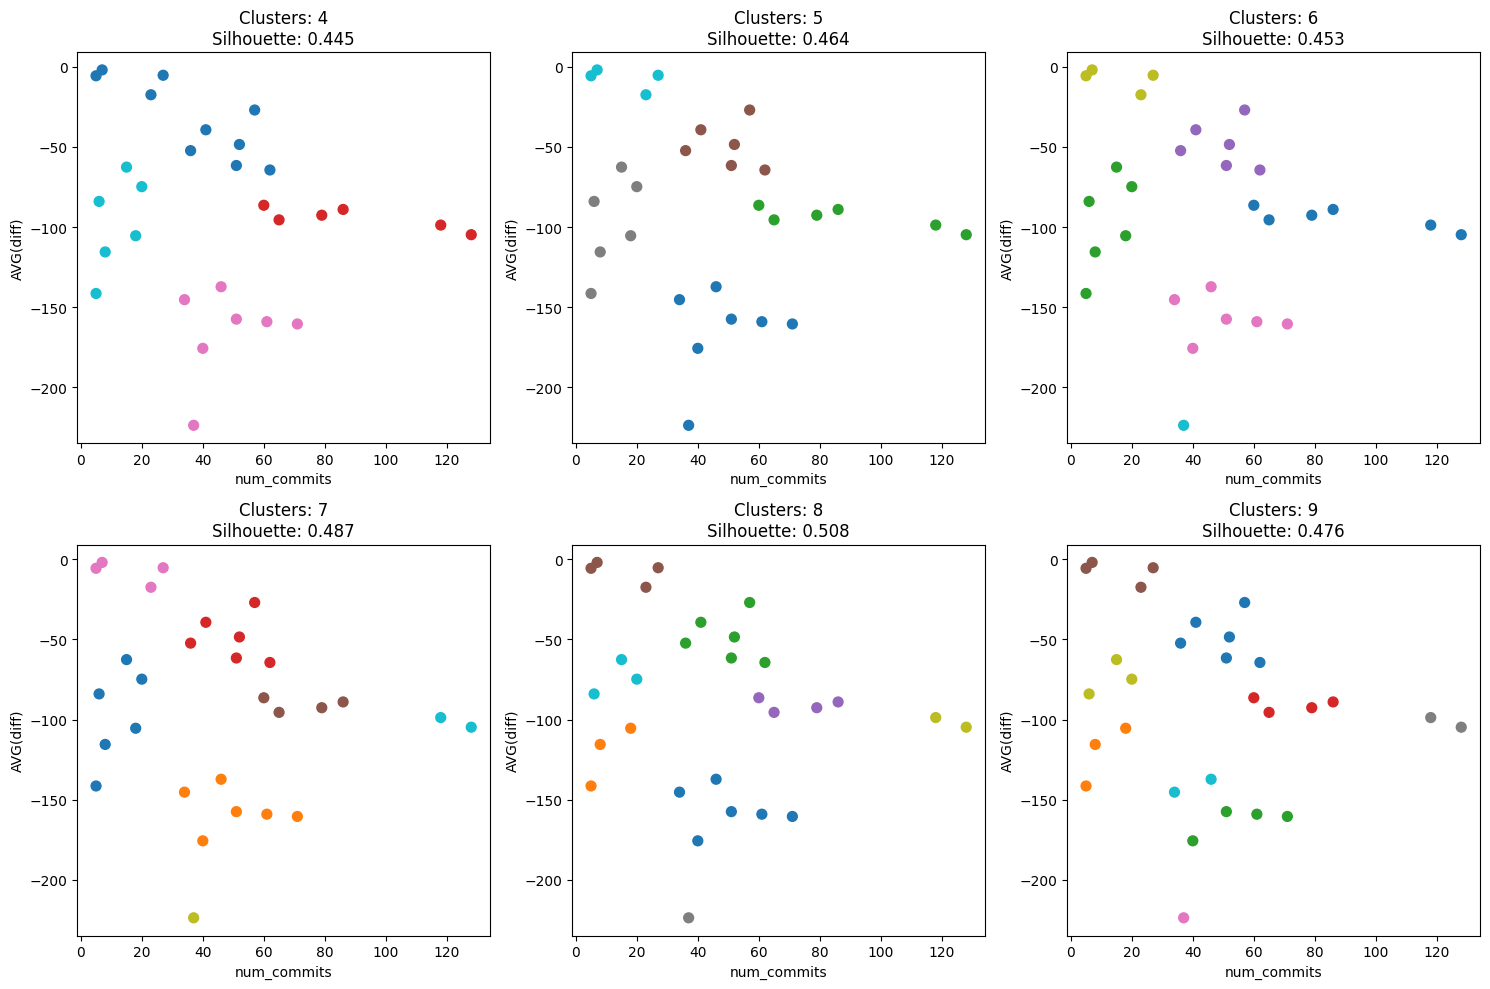

Silhouette score for n_clusters=5: 0.464


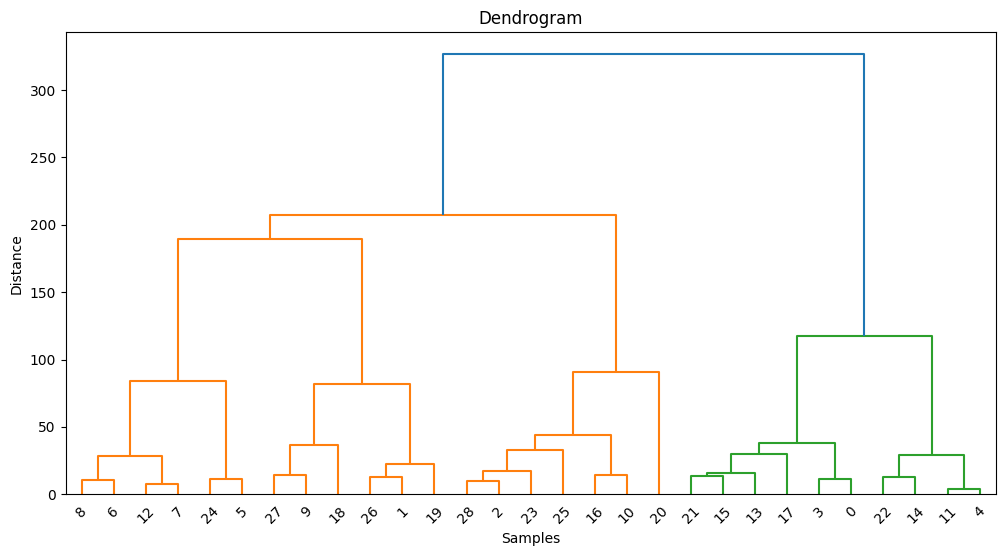

In [105]:
n_clusters = 5
agglo = AgglomerativeClustering(n_clusters=n_clusters)
labels = agglo.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels, cmap='tab10', s=50)
plt.title(f'Agglomerative Clustering (n_clusters={n_clusters})')
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.show()

plt.figure(figsize=(15,10))
n_clusters_list = [4, 5, 6, 7, 8,9]
for idx, n in enumerate(n_clusters_list, 1):
    agg = AgglomerativeClustering(n_clusters=n)
    lbls = agg.fit_predict(X)
    score = silhouette_score(X, lbls)
    plt.subplot(2, 3, idx)
    plt.scatter(X['num_commits'], X['AVG(diff)'], c=lbls, cmap='tab10', s=50)
    plt.title(f'Clusters: {n}\nSilhouette: {score:.3f}')
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
plt.tight_layout()
plt.show()

score = silhouette_score(X, labels)
print(f'Silhouette score for n_clusters=5: {score:.3f}')

linked = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           labels=X.index.to_list(),
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [106]:
def optimize_and_plot(model_class, model_params, param_name, param_range, X):
    scores = []
    best_score = -1
    best_param = None
    best_labels = None

    for val in param_range:
        params = model_params.copy()
        params[param_name] = val
        model = model_class(**params)
        labels = model.fit_predict(X)
        unique_labels = set(labels)
        if len(unique_labels) > 1 and -1 not in unique_labels:
            score = silhouette_score(X, labels)
        else:
            score = float('nan')
        scores.append(score)
        if score > best_score:
            best_score = score
            best_param = val
            best_labels = labels

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(param_range, scores, marker='o')
    axes[0].set_title('Silhouette Score vs ' + param_name)
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('Silhouette Score')
    axes[1].scatter(X[:, 0], X[:, 1], c=best_labels, cmap='tab10', s=50)
    axes[1].set_title(f'Best Clusters (best {param_name}={best_param})')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    plt.tight_layout()
    plt.show()
    return best_param, best_score

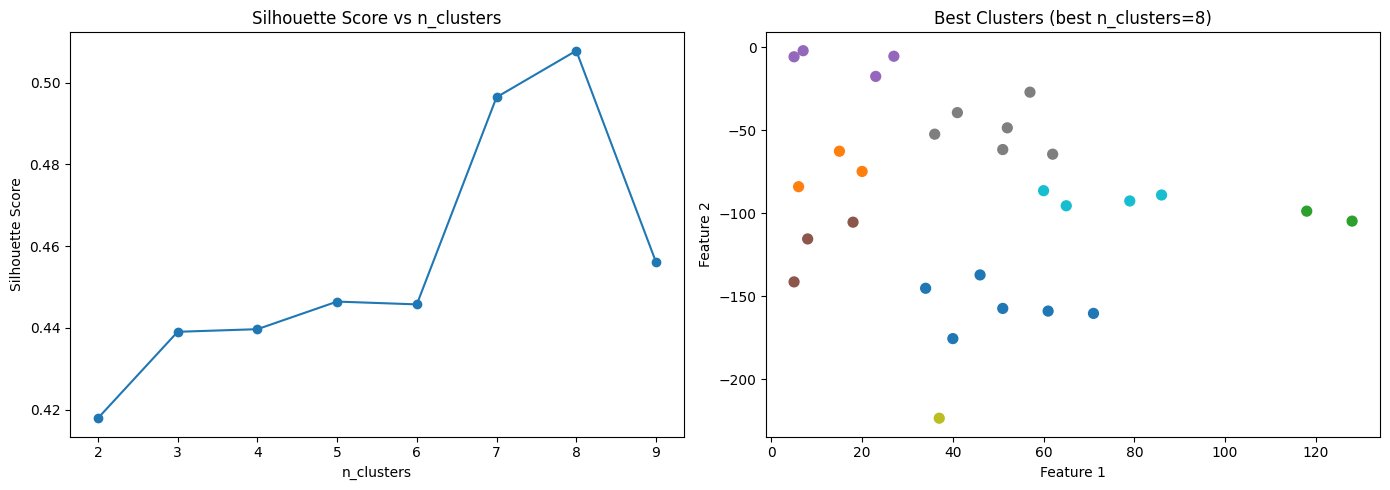

Лучшее n_clusters = 8 с silhouette = 0.508


In [107]:
X_array = X[['num_commits', 'AVG(diff)']].to_numpy()

best_val, best_sil = optimize_and_plot(
    KMeans,
    {'random_state': 21},
    'n_clusters',
    range(2, 10),
    X_array
)

print(f"Лучшее n_clusters = {best_val} с silhouette = {best_sil:.3f}")

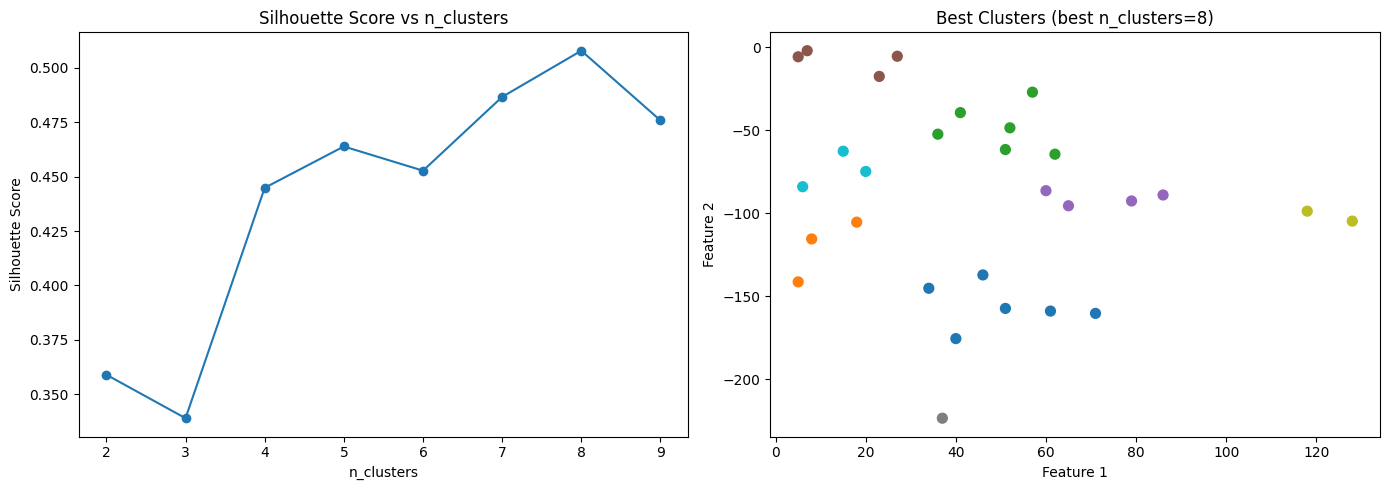

Лучшее n_clusters = 8 с silhouette = 0.508


In [108]:
X_array = X[['num_commits', 'AVG(diff)']].to_numpy()

best_n_clusters, best_score = optimize_and_plot(
    AgglomerativeClustering,
    {'linkage': 'ward'},
    'n_clusters',
    range(2, 10),
    X_array
)
print(f"Лучшее n_clusters = {best_n_clusters} с silhouette = {best_score:.3f}")

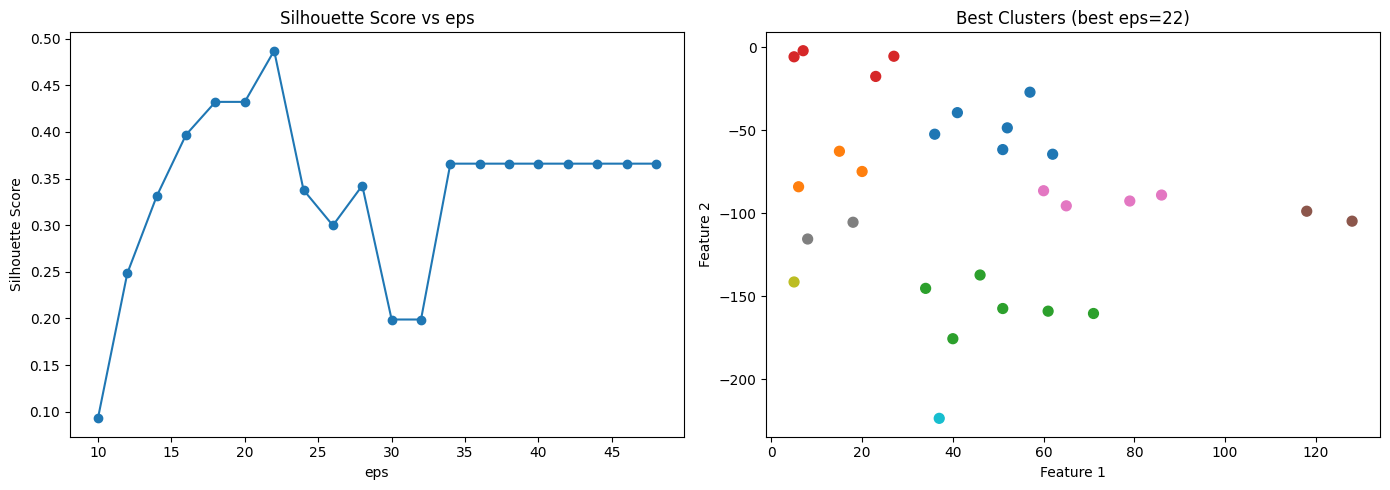

Лучший eps = 22, silhouette = 0.487


In [109]:
X_array = X[['num_commits', 'AVG(diff)']].to_numpy()

eps_range = np.arange(10, 51, 2)

best_eps, best_score = optimize_and_plot(
    DBSCAN,
    {'min_samples':1},
    'eps',
    eps_range,
    X_array
)

print(f"Лучший eps = {best_eps}, silhouette = {best_score:.3f}")